In [9]:
import math, cmath
# -------- split‑radix FFT (Task‑1 code, unchanged) ---------------------------
def sr_fft(x):
    """Split‑radix FFT: 1‑D complex DFT of a power‑of‑two list/np.ndarray x."""
    n = len(x)
    if n == 1:                              # size‑1 base‑case
        return [x[0]]
    if n == 2:                              # size‑2 base‑case
        return [x[0] + x[1], x[0] - x[1]]
    # split
    xe = x[0::2]          # even indices
    xp = x[1::4]          # 4k+1 indices
    xq = x[3::4]          # 4k+3 indices
    # recursive calls
    E  = sr_fft(xe)
    P  = sr_fft(xp)
    Q  = sr_fft(xq)
    # combine
    X = [0]*n
    m2, m4 = n//2, n//4
    for k in range(m4):
        w = cmath.exp(-2j*math.pi*k/n)          # ω_m^k
        u = cmath.exp(-2j*math.pi*3*k/n)        # ω_m^{3k}
        t1 = w*P[k]
        t2 = u*Q[k]
        X[k]          = E[k]          + t1 + t2
        X[k+m2]       = E[k]          - (t1 + t2)
        X[k+m4]       = E[k+m4]       - 1j*(t1 - t2)
        X[k+3*m4]     = E[k+m4]       + 1j*(t1 - t2)
    return X
# -------- inverse transform via conjugate‑symmetry ---------------------------
def sr_ifft(X):
    """
    Inverse DFT using the forward split‑radix routine.
    Returns the length‑N list of complex numbers representing the time series.
    """
    n = len(X)
    # inverse via conjugation:  F^{-1}(X) = conj( F( conj(X) ) ) / n
    conj_X = [z.conjugate() for z in X]
    time_dom = sr_fft(conj_X)
    return [z.conjugate()/n for z in time_dom]


In [10]:
def real_fft(u):
    """Forward FFT of a *real* list ‑‑ keep all N complex modes."""
    return sr_fft([complex(v,0.0) for v in u])

def real_ifft(Uc):
    """Inverse FFT that *returns real array* (discard tiny imag error)."""
    x = sr_ifft(Uc)
    return [z.real for z in x]

def spectral_second_derivative(Uc):
    """
    Given complex Fourier coefficients Uc[k], return coefficients of U''.
    Uses multiplier -(2πk)^2 with k∈{0,…,N-1} interpreted as signed integers.
    """
    n = len(Uc)
    Sd = [0j]*n
    for k in range(n):
        # convert k to signed frequency
        k_signed = k if k <= n//2 else k-n
        if k_signed != 0:
            Sd[k] = -(2*math.pi*k_signed)**2 * Uc[k]
        else:
            Sd[k] = 0j
    return Sd


In [11]:
import numpy as np   # only for convenience in norms / linspace / plotting

def solve_u_split_radix(eta, N=256, alpha=1.0, dealias=False,
                        tol=1e-10, max_iter=20_000):
    """
    Pure‑Python solver using split‑radix FFT.
      * eta      : parameter in the E‑L equation
      * N        : power‑of‑two grid size
      * alpha    : relaxation factor  (α=1 ⇒ no damping)
      * dealias  : True ⇒ zero top 1/3 of modes of nonlinear RHS  (2/3‑rule)
    """
    # grid in physical space
    X = np.linspace(0.0, 1.0, N, endpoint=False)
    U  = np.zeros(N)             # initial guess  (mean‑zero, periodic)
    if eta == 0.0:
        return U                 # trivial solution
    
    const = 4*math.pi*math.sqrt(2)*eta**2
    
    for it in range(max_iter):
        # 1) build nonlinear RHS f(X) = const * sin(2π(X + √2 U))
        f = const * np.sin(2*math.pi*(X + math.sqrt(2)*U))
        f -= f.mean()            # enforce zero mean for solvability
        
        # 2) (optional) dealias in Fourier space
        f_hat = real_fft(f)
        if dealias:
            Kcut = N//3          # keep lowest 2/3 ⇒ zero out k > N/3
            for k in range(N):
                k_alias = k if k <= N//2 else k-N
                if abs(k_alias) > Kcut:
                    f_hat[k] = 0.0j
        
        # 3) solve U_new'' = f  ⇒  in Fourier space  U_hat = -f_hat/(2πk)^2
        U_hat = [0j]*N
        for k in range(N):
            k_signed = k if k <= N//2 else k-N
            if k_signed != 0:
                U_hat[k] = -f_hat[k] / ((2*math.pi*k_signed)**2)
            else:
                U_hat[k] = 0.0j   # mean‑zero constraint
        
        U_new = np.array(real_ifft(U_hat))
        
        # 4) relaxation update
        U_next = (1-alpha)*U + alpha*U_new
        # 5) convergence test
        if np.linalg.norm(U_next-U) < tol:
            print(f"η={eta:4.1f}: converged in {it+1} iterations.")
            return U_next
        U = U_next
    print(f"η={eta:4.1f}: reached max_iter {max_iter} without full convergence.")
    return U


η= 0.3: converged in 13 iterations.
η= 1.0: converged in 77 iterations.
η= 3.0: converged in 376 iterations.


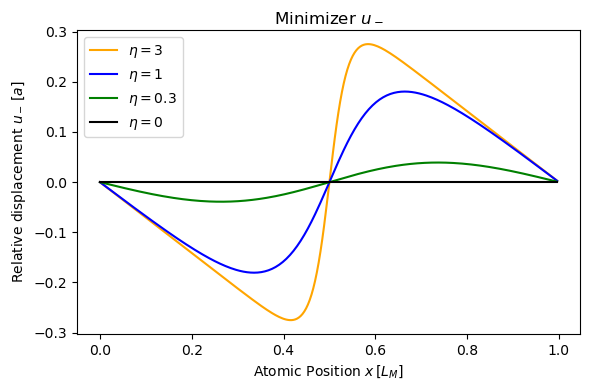

In [12]:
# choose grid size (power of 2)
N = 256

# heuristic choices:  small η → α=1 ;  larger η → heavy damping & dealiasing
settings = {0.0:(1.0,False),
            0.3:(1.0,False),
            1.0:(0.25,False),
            3.0:(0.05,True)}

solutions = {}
for eta in [0.0,0.3,1.0,3.0]:
    alpha,dealias = settings[eta]
    solutions[eta] = solve_u_split_radix(eta,N,alpha,dealias)

# ---------------- plotting (matplotlib) --------------------------------------
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
colors = {3.0:'orange',1.0:'blue',0.3:'green',0.0:'black'}
labels = {3.0:r'$\eta = 3$',1.0:r'$\eta = 1$',0.3:r'$\eta = 0.3$',0.0:r'$\eta = 0$'}
X = np.linspace(0,1,N,endpoint=False)
for eta in [3.0,1.0,0.3,0.0]:
    plt.plot(X, solutions[eta], color=colors[eta], label=labels[eta])
plt.title("Minimizer $u_-$")
plt.xlabel(r"Atomic Position $x\,[L_M]$")
plt.ylabel(r"Relative displacement $u_-\, [a]$")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


η = 0.00, N = 512, α = 1.0, dealias = False
η = 0.30, N = 512, α = 1.0, dealias = False
  converged in 13 iterations (α=1.0).
η = 1.00, N = 512, α = 0.25, dealias = False
  converged in 78 iterations (α=0.25).
η = 3.00, N = 512, α = 0.05, dealias = True
  converged in 380 iterations (α=0.05).
η = 3.20, N = 512, α = 0.05, dealias = True
η = 3.40, N = 512, α = 0.05, dealias = True
η = 3.60, N = 512, α = 0.05, dealias = True
η = 3.80, N = 512, α = 0.05, dealias = True
η = 4.00, N = 512, α = 0.05, dealias = True


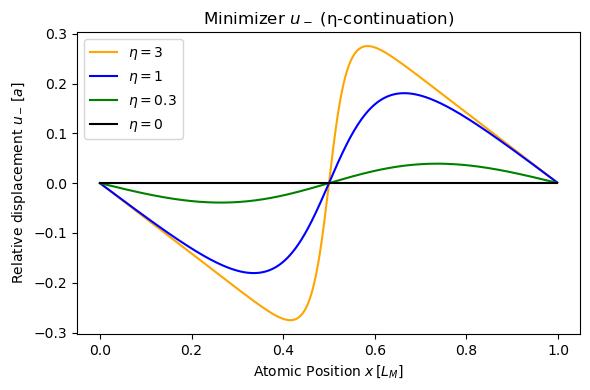

In [13]:
"""
moiré_eta_continuation.py
Solve 1‑D Euler–Lagrange equation
   -U''/eta**2 + 4π√2 sin(2π (X + √2 U)) = 0
with periodic BC and zero mean, using
   • split‑radix FFT  (pure Python, no numpy.fft)
   • Picard iteration + under‑relaxation
   • η‑continuation to reach large non‑linearity
"""

# --------------------------------------------------------------------
# 0.  Imports
# --------------------------------------------------------------------
import math, cmath
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------------
# 1.  Split‑radix FFT and inverse  (Task‑1 algorithm)
# --------------------------------------------------------------------
def sr_fft(x):
    """Split‑radix FFT of complex list/1‑D ndarray x, length must be 2^p."""
    n = len(x)
    if n == 1:
        return [x[0]]
    if n == 2:                       # trivial butterfly
        return [x[0]+x[1], x[0]-x[1]]
    xe = x[0::2]                     # even indices
    xp = x[1::4]                     # 4k+1
    xq = x[3::4]                     # 4k+3
    E  = sr_fft(xe)
    P  = sr_fft(xp)
    Q  = sr_fft(xq)
    X  = [0]*n
    m2, m4 = n//2, n//4
    for k in range(m4):
        w = cmath.exp(-2j*math.pi*k/n)
        u = cmath.exp(-2j*math.pi*3*k/n)
        t1 = w * P[k]
        t2 = u * Q[k]
        X[k]          = E[k]       + t1 + t2
        X[k+m2]       = E[k]       - (t1 + t2)
        X[k+m4]       = E[k+m4]    - 1j*(t1 - t2)
        X[k+3*m4]     = E[k+m4]    + 1j*(t1 - t2)
    return X

def sr_ifft(X):
    """Inverse DFT via conjugate symmetry: F^{-1}(X) = conj(F(conj(X)))/n."""
    n = len(X)
    conj_X = [z.conjugate() for z in X]
    time   = sr_fft(conj_X)
    return [z.conjugate()/n for z in time]

# Convenience wrappers for *real* signals
def real_fft(u):
    return sr_fft([complex(v,0.0) for v in u])

def real_ifft(Uc):
    return [z.real for z in sr_ifft(Uc)]

# --------------------------------------------------------------------
# 2.  Spectral utilities
# --------------------------------------------------------------------
def spectral_second_derivative(U_hat):
    """Return Fourier coefficients of U'' given coefficients of U."""
    n = len(U_hat)
    D2_hat = [0j]*n
    for k in range(n):
        k_signed = k if k <= n//2 else k - n
        if k_signed != 0:
            D2_hat[k] = - (2*math.pi*k_signed)**2 * U_hat[k]
    return D2_hat

# --------------------------------------------------------------------
# 3.  Picard solver with relaxation + optional 2/3‑dealiasing
# --------------------------------------------------------------------
def solve_u_picard(eta, N, alpha, dealias, U0=None,
                   tol=1e-10, max_iter=20_000, verbose=False):
    """
    Picard fixed‑point solver (under‑relaxed) for one η.
      * eta      : parameter in the E‑L equation
      * N        : grid size  (power of 2)
      * alpha    : relaxation factor (0<alpha≤1)
      * dealias  : bool → apply 2/3‑rule to nonlinear RHS
      * U0       : initial guess (array length N) or None → zeros
    Returns ndarray U (solution on grid X_j = j/N).
    """
    X = np.linspace(0.0, 1.0, N, endpoint=False)
    U = np.zeros(N) if U0 is None else U0.copy()
    if eta == 0.0:
        return U

    const = 4 * math.pi * math.sqrt(2) * eta**2

    for it in range(max_iter):
        # nonlinear RHS
        RHS = const * np.sin(2*math.pi * (X + math.sqrt(2)*U))
        RHS -= RHS.mean()         # enforce ∫RHS = 0

        # dealias in Fourier space if requested
        RHS_hat = real_fft(RHS)
        if dealias:
            k_cut = N//3
            for k in range(N):
                k_alias = k if k <= N//2 else k - N
                if abs(k_alias) > k_cut:
                    RHS_hat[k] = 0.0j

        # solve U_new'' = RHS  ⇒  U_hat = -RHS_hat / (2πk)^2
        U_hat = [0j]*N
        for k in range(N):
            k_signed = k if k <= N//2 else k - N
            if k_signed != 0:
                U_hat[k] = - RHS_hat[k] / ((2*math.pi*k_signed)**2)
        U_new = np.array(real_ifft(U_hat))

        # under‑relaxation
        U_next = (1-alpha)*U + alpha*U_new

        # convergence test
        if np.linalg.norm(U_next - U) < tol:
            if verbose:
                print(f"  converged in {it+1} iterations (α={alpha}).")
            return U_next
        U = U_next

    if verbose:
        print("  WARNING: max_iter reached without full convergence.")
    return U

# --------------------------------------------------------------------
# 4.  η‑continuation driver
# --------------------------------------------------------------------
def continuation_solver(eta_grid, N=512,
                        alpha_small=1.0, alpha_medium=0.25,
                        alpha_large=0.05,
                        verbose=True):
    """
    eta_grid : iterable of η values in *ascending* order, e.g. [0.3,1,3,3.2,3.4,…,4]
    Returns  dict {η: U_η (ndarray length N)}.
    """
    solutions = {}
    U_prev    = None
    for eta in eta_grid:
        # choose heuristic α & dealias
        if eta < 1.0:
            alpha = alpha_small
            deal  = False
        elif eta < 3.0:
            alpha = alpha_medium
            deal  = False
        else:
            alpha = alpha_large
            deal  = True

        if verbose:
            print(f"η = {eta:.2f}, N = {N}, α = {alpha}, dealias = {deal}")

        U_prev = solve_u_picard(eta=eta, N=N, alpha=alpha, dealias=deal,
                                U0=U_prev, verbose=verbose)
        solutions[eta] = U_prev
    return solutions

# --------------------------------------------------------------------
# 5.  Main program  (define η‑path, call solver, plot)
# --------------------------------------------------------------------
if __name__ == "__main__":

    # grid of η values:  start at 3.0 (assumed converged) → 4.0 in steps of 0.2
    eta_grid = [0.0, 0.3, 1.0] + list(np.arange(3.0, 4.01, 0.2))  # 3.0,3.2,…,4.0
    N_grid   = 512         # power‑of‑two grid resolution

    solutions = continuation_solver(eta_grid, N=N_grid, verbose=True)

    # ----------------------------------------------------------------
    # Plot selected curves in the requested style
    # ----------------------------------------------------------------
    plot_etas = [4.0, 3.0, 1.0, 0.3, 0.0]      # order = orange, blue, …
    colors    = {4.0:'red', 3.0:'orange', 1.0:'blue',
                 0.3:'green', 0.0:'black'}
    labels    = {4.0:r'$\eta = 4$', 3.0:r'$\eta = 3$', 1.0:r'$\eta = 1$',
                 0.3:r'$\eta = 0.3$', 0.0:r'$\eta = 0$'}
    X = np.linspace(0.0, 1.0, N_grid, endpoint=False)

    plt.figure(figsize=(6,4))
    for eta in plot_etas:
        if eta in solutions:
            plt.plot(X, solutions[eta], color=colors[eta], label=labels[eta])
    plt.title("Minimizer $u_-$ (η‑continuation)")
    plt.xlabel(r"Atomic Position $x\,[L_M]$")
    plt.ylabel(r"Relative displacement $u_-\, [a]$")
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()
